In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [ ]:
## computation time is in MILLISECONDS

data = pd.read_csv("stats_all.csv")
data["Length"] = data["Length"].apply(lambda l: int(np.log2(l)))

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Length     336 non-null    int64  
 1   Quicksort  272 non-null    float64
 2   Mergesort  336 non-null    float64
 3   Bitsort    336 non-null    float64
 4   Speedup_q  272 non-null    float64
 5   Speedup_m  336 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 15.9 KB


In [52]:
quick = data.groupby("Length")["Quicksort"]
quick.describe()

,count,mean,std,min,25%,50%,75%,max
Length,,,,,,,,
10,16.0,0.043901,0.001658,0.040607,0.042967,0.043894,0.045339,0.046148
11,16.0,0.089966,0.001980,0.086135,0.088910,0.089927,0.091285,0.092847
12,16.0,0.192499,0.004165,0.185835,0.189420,0.192078,0.195770,0.200303
13,16.0,0.390501,0.005878,0.379165,0.387088,0.389986,0.395499,0.399264
14,16.0,0.815850,0.017958,0.790943,0.803292,0.815941,0.824615,0.847171
15,16.0,1.679135,0.052877,1.633656,1.650452,1.665527,1.690587,1.859287
16,16.0,3.104175,0.367240,2.755241,2.776392,2.917327,3.489075,3.629945
17,16.0,6.525387,0.071085,6.408591,6.497486,6.531527,6.568002,6.695029
18,16.0,17.330701,0.132513,17.057505,17.243057,17.370969,17.416765,17.501885


In [53]:
merge = data.groupby("Length")["Mergesort"]
merge.describe()

,count,mean,std,min,25%,50%,75%,max
Length,,,,,,,,
10,16.0,0.061679,0.001466,0.060415,0.060867,0.061152,0.061733,0.066206
11,16.0,0.133147,0.001051,0.131882,0.132626,0.132925,0.133278,0.136572
12,16.0,0.289778,0.005444,0.284765,0.287315,0.288021,0.290178,0.305645
13,16.0,0.620356,0.009152,0.613975,0.615475,0.616144,0.620371,0.648361
14,16.0,1.308072,0.015490,1.288405,1.294927,1.309179,1.316258,1.333641
15,16.0,2.694746,0.013819,2.680699,2.685072,2.688514,2.701380,2.722709
16,16.0,4.850870,0.577028,4.304385,4.346443,4.533278,5.528210,5.718090
17,16.0,8.967297,0.126822,8.828140,8.839314,8.986488,9.085318,9.136811
18,16.0,18.599221,0.260393,18.169873,18.350466,18.624854,18.829966,18.927723


In [54]:
bit = data.groupby("Length")["Bitsort"]
bit.describe()

,count,mean,std,min,25%,50%,75%,max
Length,,,,,,,,
10,16.0,0.061772,0.010312,0.055076,0.056926,0.057209,0.061859,0.095804
11,16.0,0.077786,0.004674,0.073410,0.074162,0.074593,0.081656,0.086365
12,16.0,0.099435,0.003956,0.094772,0.095447,0.100222,0.102751,0.105672
13,16.0,0.129166,0.001186,0.127234,0.128236,0.129147,0.130006,0.131592
14,16.0,0.162725,0.002990,0.159044,0.160672,0.161919,0.163502,0.170466
15,16.0,0.207002,0.005106,0.201816,0.203276,0.204852,0.211094,0.217436
16,16.0,0.283943,0.010932,0.273053,0.277107,0.283337,0.285792,0.318549
17,16.0,0.449875,0.030289,0.431205,0.435531,0.438800,0.447696,0.540835
18,16.0,0.778855,0.057628,0.697675,0.753950,0.781219,0.792213,0.934248


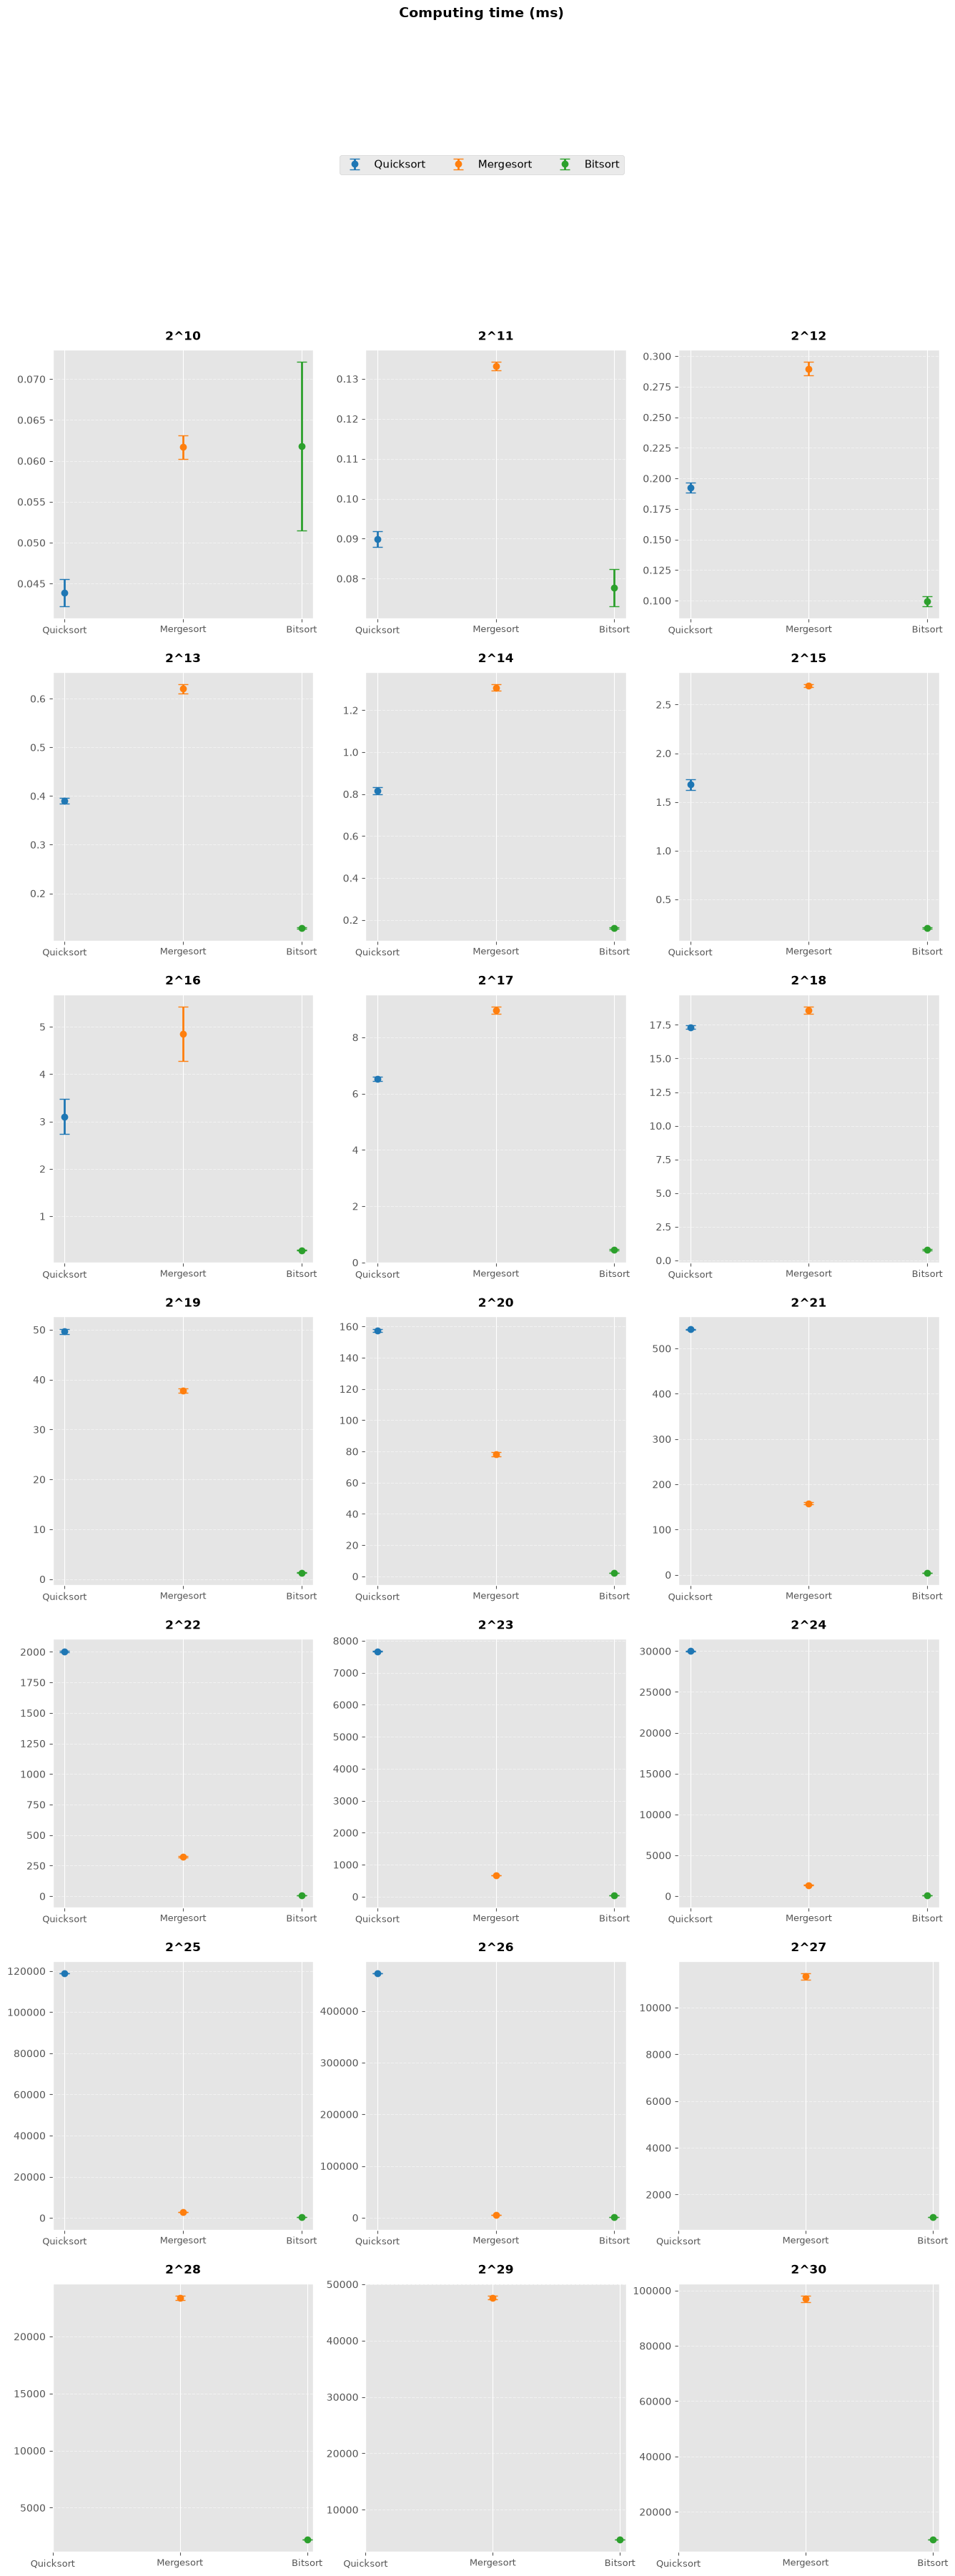

In [81]:
# 2. Configurazione della griglia di Subplot
# Creiamo una griglia dinamica in base al numero di elementi nell'indice
num_plots = len(bit)
num_col = 3
num_row = int (num_plots / num_col)

fig = plt.figure(figsize=(16, 40))

# Lista dei DataFrame, colori e relative etichette per il ciclo
index_points = bit.describe().index
dataframes = [quick.describe(), merge.describe(), bit.describe()]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # Blu, Arancione, Verde
labels = ["Quicksort", "Mergesort", "Bitsort"]
x_positions = [0, 1, 2]  # Posizioni delle 3 barre d'errore all'interno di ogni subplot

# 3. Costruzione dei grafici punto per punto
for i, idx_val in enumerate(index_points):
    ax = plt.subplot(num_row, num_col, i+1, sharey=None)

    # Estraiamo e tracciamo i dati di ogni DataFrame per il punto corrente dell'indice
    for df, label, color, x_pos in zip(dataframes, labels, colors, x_positions):
        mean_val = df.loc[idx_val, "mean"]
        std_val = df.loc[idx_val, "std"]

        # Disegna la barra d'errore
        ax.errorbar(
            x_pos,
            mean_val,
            yerr=std_val,
            fmt="o",  # 'o' indica un marker circolare per la media
            color=color,
            markersize=6,
            linewidth=2,
            capsize=5,  # Larghezza delle alette orizzontali dell'errore
            label=label if i == 0 else "",  # Mette la legenda solo nel primo grafico per evitare duplicati
        )

    # Personalizzazione del singolo subplot
    ax.set_title(f"2^{idx_val}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

# 4. Personalizzazione globale e Legenda
fig.suptitle(
    "Computing time (ms)",
    fontsize=14,
    fontweight="bold",
    y=1,
)
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.95), ncol=3, fontsize=11)

# plt.tight_layout()
plt.show(fig)
plt.close(fig)